In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px

df = pd.read_csv(r"C:\Users\USER\Downloads\Aircraft_Component_Reliability_Dataset.csv")
df['Failure_Date'] = pd.to_datetime(df['Failure_Date'])
df['Year'] = df['Failure_Date'].dt.year
df['Quarter'] = df['Failure_Date'].dt.to_period('Q')

df.head(15)



,Aircraft_ID,Component_Name,ATA_Code,Flight_Hours_Since_Install,Flight_Cycles_Since_Install,Failure_Date,Vendor,Failure_Cause,Repair_Time_Hours,Repair_Cost_USD,MTBF_Hours,MTTR_Hours,Downtime_Hours,Year,Quarter
0,AC0052,Hydraulic Pump,22,8418,2568,2022-03-04,Airbus,Wear & Tear,7.97,3012.22,297.04,5.76,5.05,2022,2022Q1
1,AC0093,Flight Control System,29,4594,2760,2016-04-01,Boeing,Manufacturing Defect,5.45,752.90,308.24,4.84,14.18,2016,2016Q2
2,AC0015,Navigation System,27,8984,3051,2015-04-13,Honeywell,Wear & Tear,16.19,2238.10,456.75,3.85,12.00,2015,2015Q2
3,AC0072,Engine Turbine,28,5710,3618,2023-04-26,Honeywell,Poor Maintenance,6.93,1353.04,378.33,3.13,12.03,2023,2023Q2
4,AC0061,Landing Gear,26,6124,2010,2018-01-31,Safran,Wear & Tear,9.12,1377.64,442.43,4.89,21.78,2018,2018Q1
5,AC0021,Landing Gear,26,2398,958,2017-09-30,Honeywell,Manufacturing Defect,12.08,2069.01,699.13,4.68,18.35,2017,2017Q3
6,AC0083,Air Conditioning Unit,29,6900,1578,2017-07-03,Rolls Royce,Wear & Tear,10.02,2345.62,324.55,3.81,12.17,2017,2017Q3
7,AC0087,Engine Turbine,24,4452,3424,2016-07-25,Airbus,Overuse,8.23,1462.26,544.94,4.62,12.83,2016,2016Q3
8,AC0075,Navigation System,25,800,850,2023-04-05,Safran,Environmental,9.55,1445.97,322.28,5.38,7.56,2023,2023Q2
9,AC0075,Engine Turbine,29,9110,2063,2016-02-24,Safran,Unknown,8.17,1352.55,299.76,6.60,14.58,2016,2016Q1


In [52]:
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Aircraft_ID                  5000 non-null   object        
 1   Component_Name               5000 non-null   object        
 2   ATA_Code                     5000 non-null   int64         
 3   Flight_Hours_Since_Install   5000 non-null   int64         
 4   Flight_Cycles_Since_Install  5000 non-null   int64         
 5   Failure_Date                 5000 non-null   datetime64[ns]
 6   Vendor                       5000 non-null   object        
 7   Failure_Cause                5000 non-null   object        
 8   Repair_Time_Hours            5000 non-null   float64       
 9   Repair_Cost_USD              5000 non-null   float64       
 10  MTBF_Hours                   5000 non-null   float64       
 11  MTTR_Hours                   5000 non-null 

# Reliability Metrics


In [53]:
metrics = df.groupby("Component_Name").agg({
    "MTBF_Hours": "mean",
    "MTTR_Hours": "mean",
    "Aircraft_ID": "count"
}).rename(columns={"Aircraft_ID": "Failure_Count"}).sort_values(by="Failure_Count", ascending=False)
metrics.head()


,MTBF_Hours,MTTR_Hours,Failure_Count
Component_Name,,,
Electrical Generator,502.159293,4.983116,552
Air Conditioning Unit,485.820781,4.956914,538
Engine Turbine,505.172433,5.025977,522
Avionics Module,504.442529,4.923098,510
Hydraulic Pump,505.011700,5.014130,494


# Step 2: Failure Trends and Visualization

C:\Users\USER\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



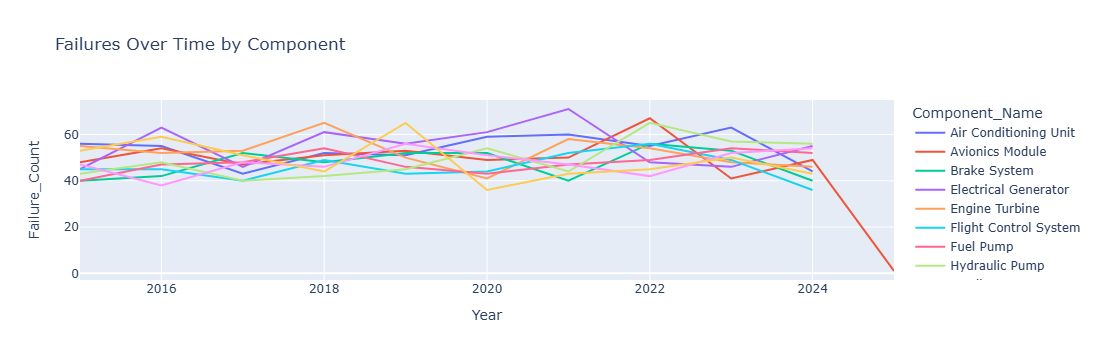

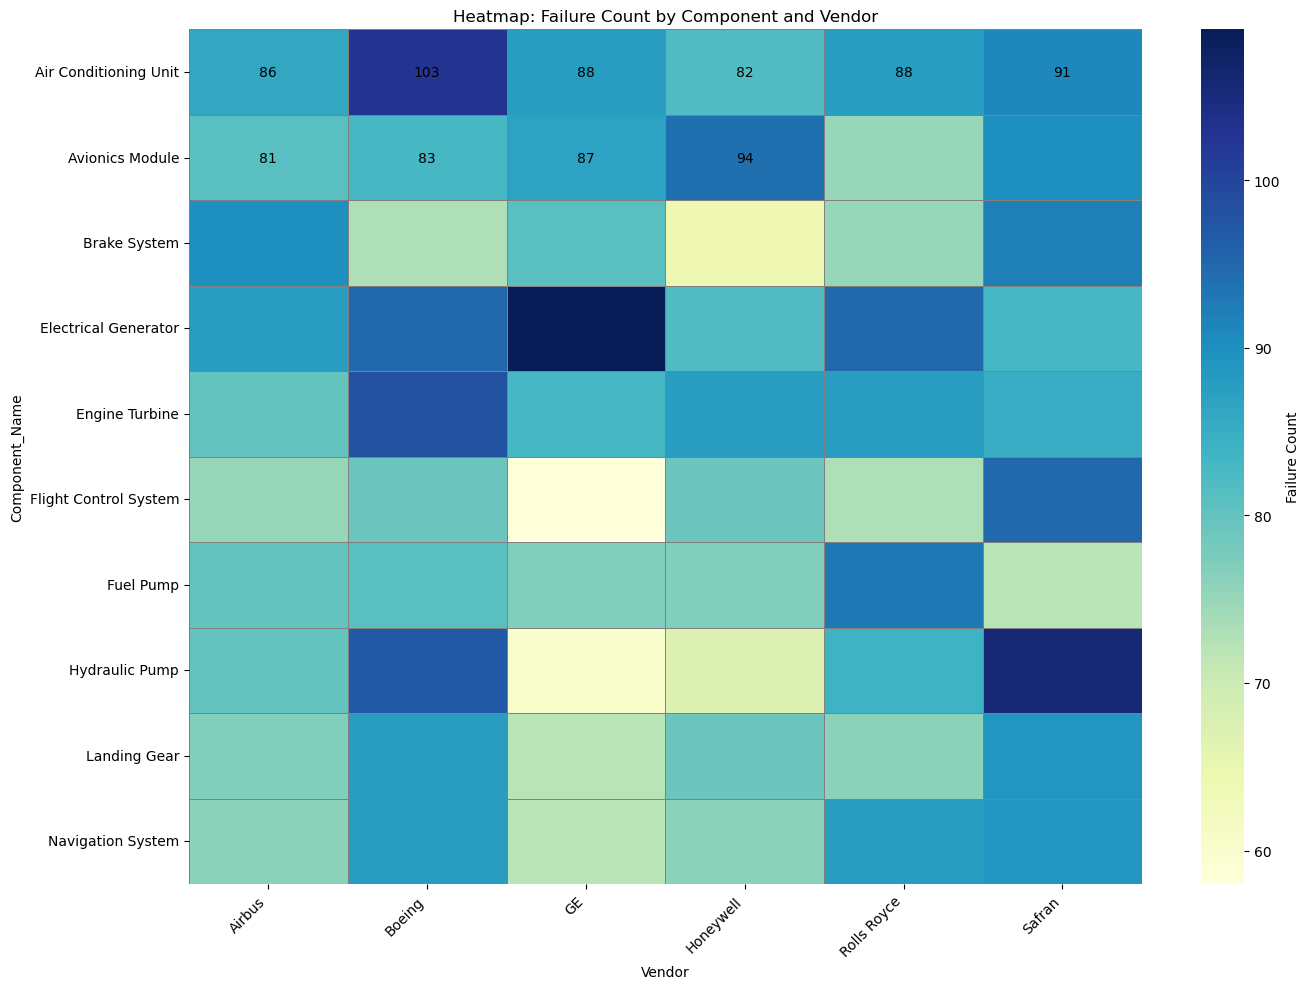

In [56]:
failures_over_time = df.groupby(['Year', 'Component_Name']).size().reset_index(name='Failure_Count')
fig = px.line(failures_over_time, x='Year', y='Failure_Count', color='Component_Name', title='Failures Over Time by Component')
fig.show()

heatmap_data = df.pivot_table(index='Component_Name', columns='Vendor', values='Aircraft_ID', aggfunc='count', fill_value=0)
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"color": "black"},
    cbar_kws={'label': 'Failure Count'}
)
plt.title("Heatmap: Failure Count by Component and Vendor")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

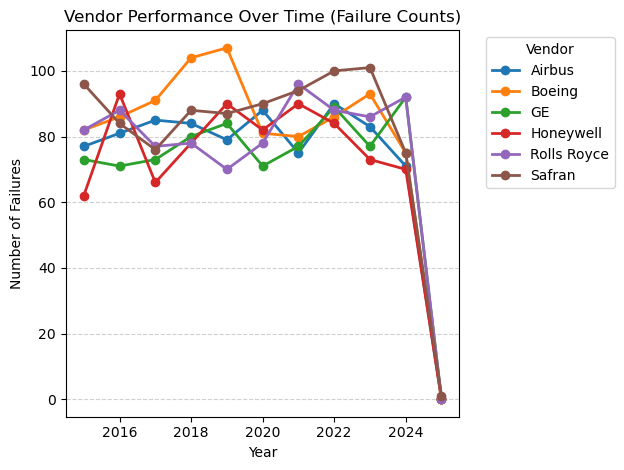

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Failure_Date'] = pd.to_datetime(df['Failure_Date'], errors='coerce')
df['Year'] = df['Failure_Date'].dt.year

vendor_trends = df.groupby(['Year', 'Vendor']).size().reset_index(name='Failure_Count')

pivot_trend = vendor_trends.pivot(index='Year', columns='Vendor', values='Failure_Count').fillna(0)

plt.figure(figsize=(12, 6))
pivot_trend.plot(kind='line', marker='o', linewidth=2)
plt.title("Vendor Performance Over Time (Failure Counts)")
plt.xlabel("Year")
plt.ylabel("Number of Failures")
plt.legend(title="Vendor", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


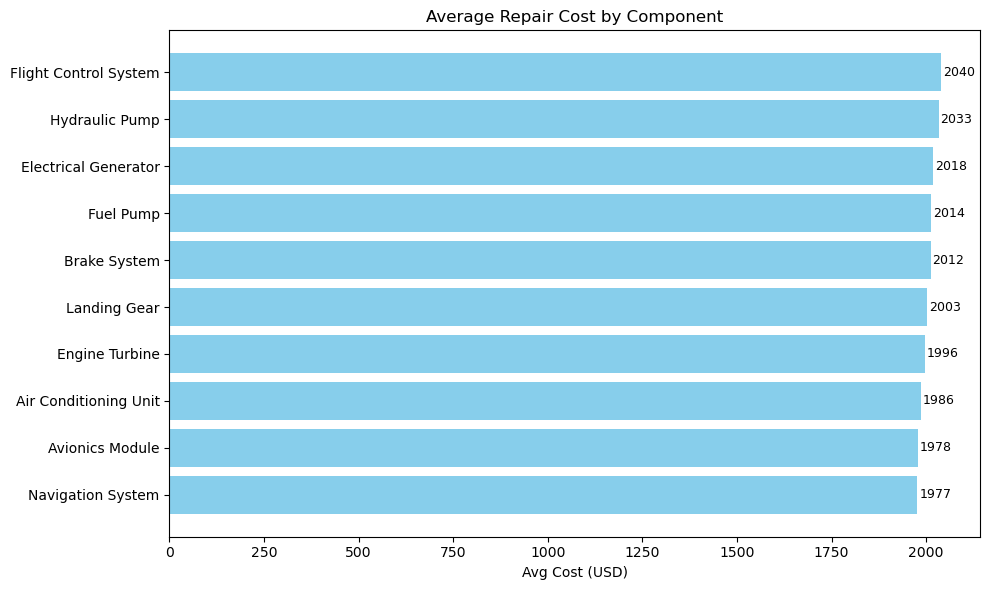

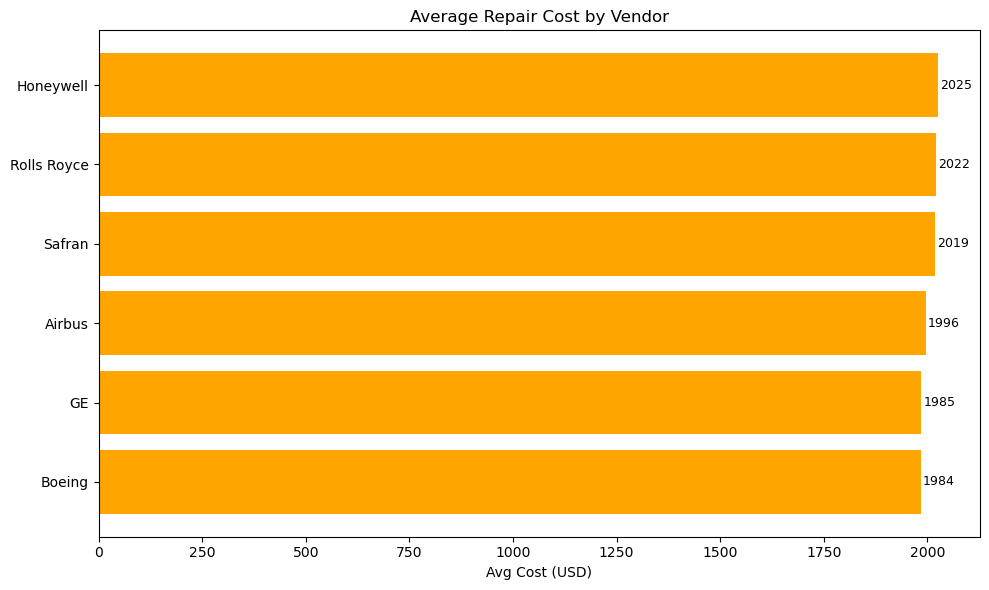

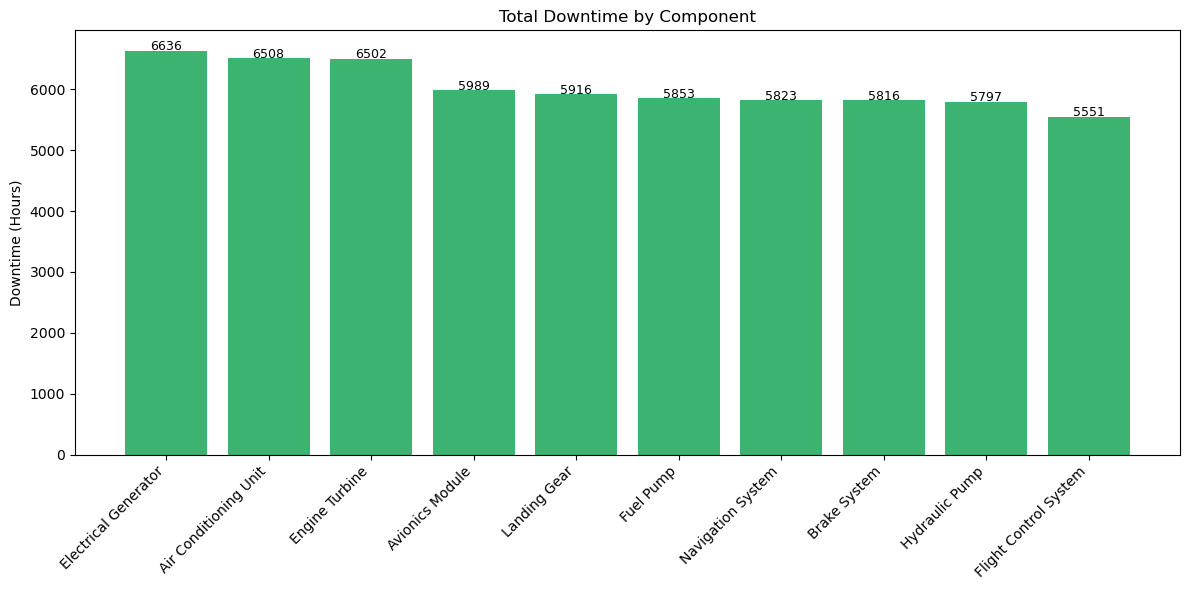

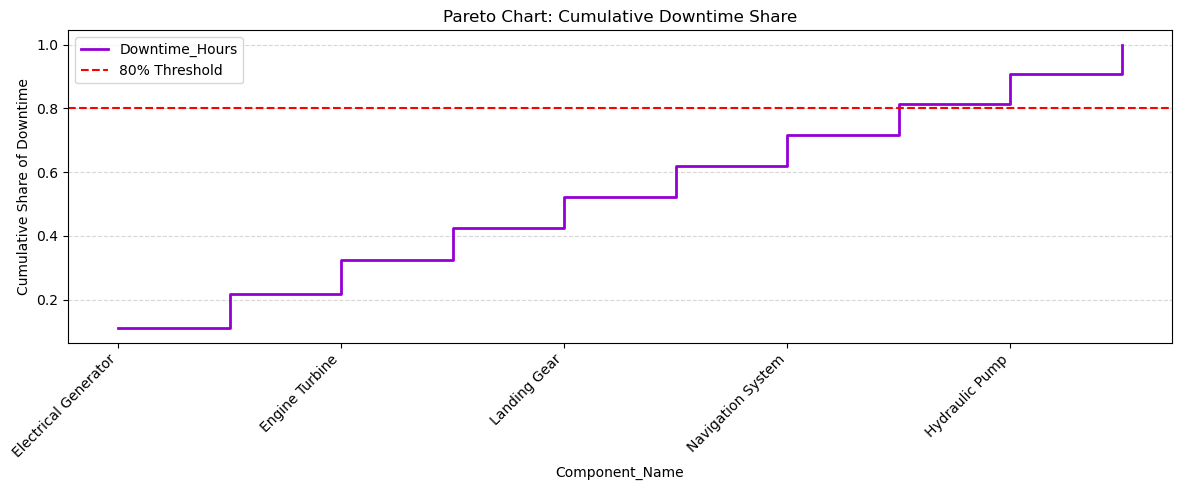

In [61]:
import matplotlib.pyplot as plt

# Average Repair Cost by Component
avg_cost_component = df.groupby("Component_Name")["Repair_Cost_USD"].mean().sort_values()
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_cost_component.index, avg_cost_component.values, color='skyblue')
plt.title('Average Repair Cost by Component')
plt.xlabel('Avg Cost (USD)')
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Average Repair Cost by Vendor
avg_cost_vendor = df.groupby("Vendor")["Repair_Cost_USD"].mean().sort_values()
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_cost_vendor.index, avg_cost_vendor.values, color='orange')
plt.title('Average Repair Cost by Vendor')
plt.xlabel('Avg Cost (USD)')
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Total Downtime by Component
downtime_by_component = df.groupby("Component_Name")["Downtime_Hours"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
bars = plt.bar(downtime_by_component.index, downtime_by_component.values, color='mediumseagreen')
plt.title('Total Downtime by Component')
plt.ylabel('Downtime (Hours)')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{bar.get_height():.0f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Pareto Chart
pareto = downtime_by_component.cumsum() / downtime_by_component.sum()
plt.figure(figsize=(12, 5))
pareto.plot(drawstyle='steps-post', title='Pareto Chart: Cumulative Downtime Share', color='darkviolet', linewidth=2)
plt.axhline(0.8, color='red', linestyle='--', label='80% Threshold')
plt.ylabel('Cumulative Share of Downtime')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
root_cause = df.groupby("Failure_Cause").agg({
    "Downtime_Hours": "sum",
    "Repair_Cost_USD": "sum",
    "MTBF_Hours": "mean",
    "MTTR_Hours": "mean"
}).sort_values(by="Downtime_Hours", ascending=False)
root_cause


,Downtime_Hours,Repair_Cost_USD,MTBF_Hours,MTTR_Hours
Failure_Cause,,,,
Overuse,11010.66,1836623.57,501.187214,4.946583
Poor Maintenance,10346.37,1703218.54,500.102633,4.989327
Wear & Tear,10252.85,1680190.77,498.502024,4.997090
Unknown,9729.45,1644542.21,501.623618,4.952887
Environmental,9563.48,1584959.84,495.259381,5.022592
Manufacturing Defect,9488.86,1577113.79,504.376061,4.981842


In [19]:
failures_by_ata_code = df.groupby("ATA_Code").size().sort_values(ascending=False)
mtbf_distribution = df["MTBF_Hours"].describe()
yearly_mtbf = df.groupby("Year")["MTBF_Hours"].mean()

high_cost_anomalies = df[df["Repair_Cost_USD"] > df["Repair_Cost_USD"].mean() + 2 * df["Repair_Cost_USD"].std()]
high_cost_anomalies[["Component_Name", "Vendor", "Repair_Cost_USD", "Failure_Date"]].head()


,Component_Name,Vendor,Repair_Cost_USD,Failure_Date
0,Hydraulic Pump,Airbus,3012.22,2022-03-04
34,Hydraulic Pump,Safran,2996.25,2018-02-13
177,Avionics Module,Airbus,3114.73,2021-09-06
200,Air Conditioning Unit,Airbus,3105.73,2015-01-14
281,Hydraulic Pump,Safran,3752.94,2015-03-28


In [28]:
pip install xgboost lightgbm scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[03:28:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[LightGBM] [Info] Number of positive: 1011, number of negative: 2989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.252750 -> initscore=-1.083999
[LightGBM] [Info] Start training from score -1.083999


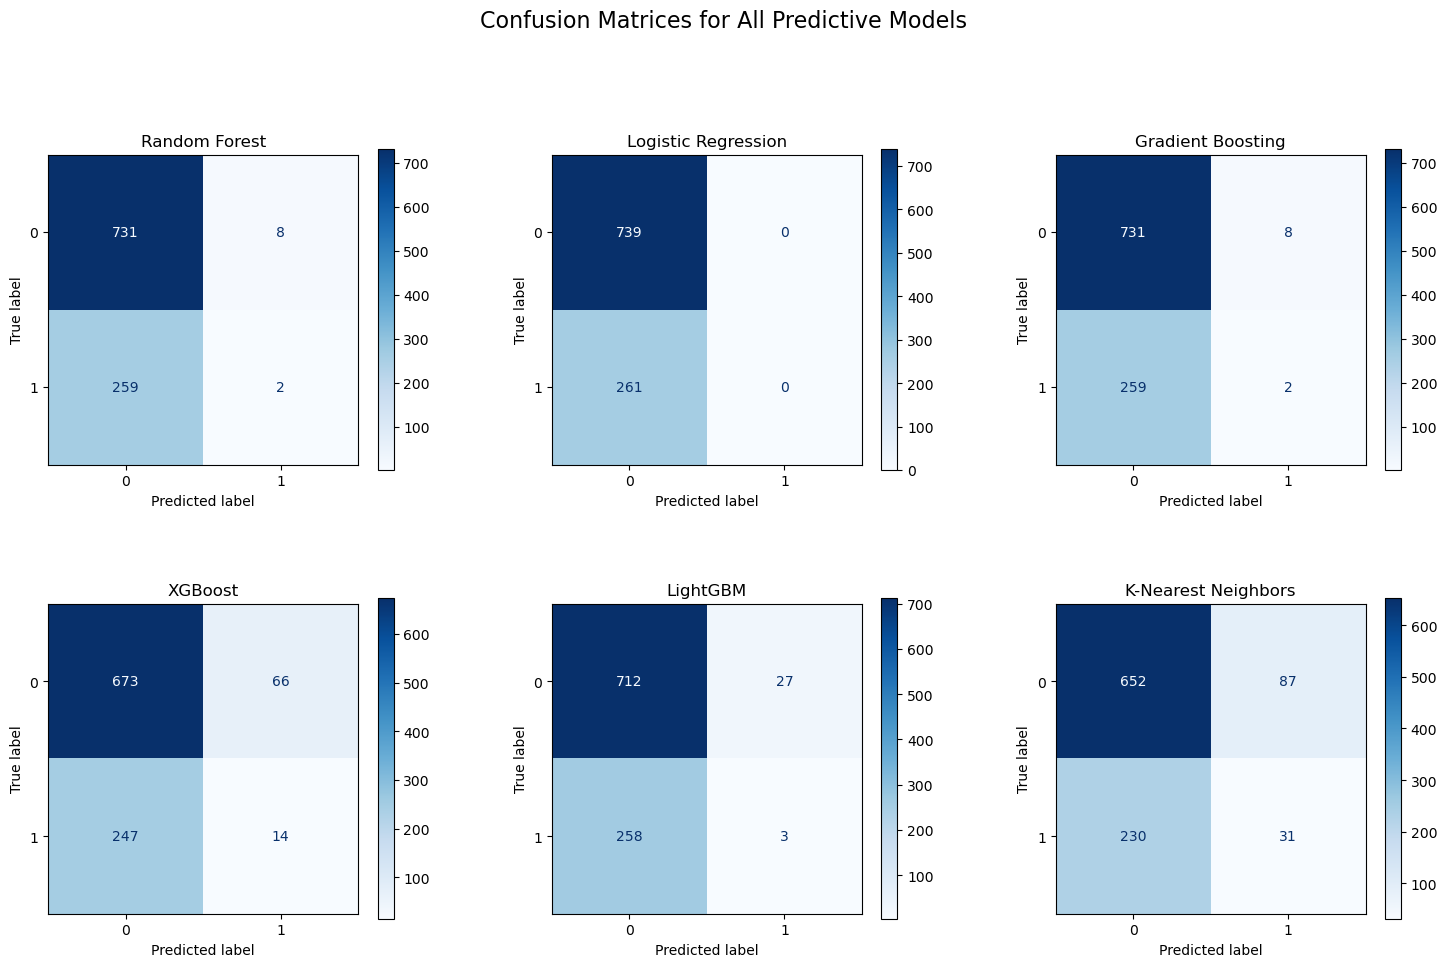



 Full Classification Reports:

🔹 Random Forest Classification Report:

              precision    recall  f1-score   support

           0      0.738     0.989     0.846       739
           1      0.200     0.008     0.015       261

    accuracy                          0.733      1000
   macro avg      0.469     0.498     0.430      1000
weighted avg      0.598     0.733     0.629      1000

------------------------------------------------------------
🔹 Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0      0.739     1.000     0.850       739
           1      0.000     0.000     0.000       261

    accuracy                          0.739      1000
   macro avg      0.369     0.500     0.425      1000
weighted avg      0.546     0.739     0.628      1000

------------------------------------------------------------
🔹 Gradient Boosting Classification Report:

              precision    recall  f1-score   support

      

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

# Load data
df = pd.read_csv(r"C:\Users\USER\Downloads\Aircraft_Component_Reliability_Dataset.csv")

# Define binary target: Failure is imminent if MTBF < 400
df['Failure_Imminent'] = df['MTBF_Hours'].apply(lambda x: 1 if x < 400 else 0)

# Feature selection
features = [
    'Flight_Hours_Since_Install', 'Flight_Cycles_Since_Install',
    'Repair_Time_Hours', 'Repair_Cost_USD',
    'Component_Name', 'Vendor', 'Failure_Cause'
]

# Encode categorical features
df_encoded = df.copy()
label_encoders = {}
for col in ['Component_Name', 'Vendor', 'Failure_Cause']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Prepare X, y
X = df_encoded[features]
y = df_encoded['Failure_Imminent']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Dynamically create a 3x2 subplot layout
n_models = len(models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()  # Flatten for indexing

performance_reports = {}

# Train and evaluate each model
for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[idx], cmap='Blues')
    axes[idx].set_title(name)

    # Capture classification report and accuracy
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    report['accuracy'] = accuracy_score(y_test, y_pred)
    performance_reports[name] = report

# Hide unused subplots (if any)
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.suptitle("Confusion Matrices for All Predictive Models", fontsize=16, y=1.02)
plt.show()

print("\n\n Full Classification Reports:\n")
for model_name, metrics in performance_reports.items():
    print(f"🔹 {model_name} Classification Report:\n")
    # Retrieve prediction from stored model
    model = models[model_name]
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print("-" * 60)


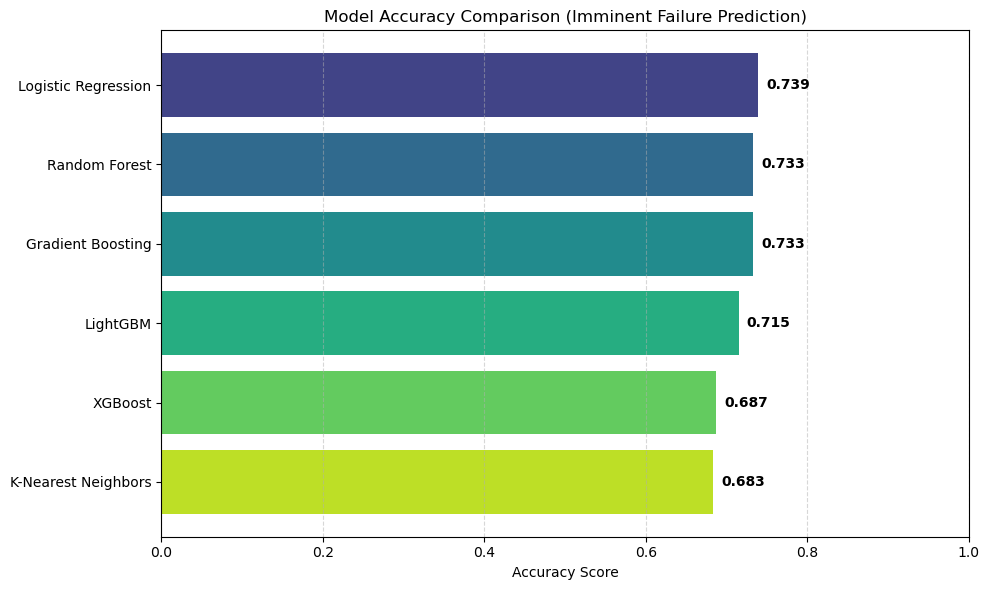

In [42]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Extract and sort accuracy scores
accuracy_scores = {
    model: round(metrics['accuracy'], 3)
    for model, metrics in performance_reports.items()
}
accuracy_scores = dict(sorted(accuracy_scores.items(), key=lambda x: x[1], reverse=True))

# Set up values
models_list = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())
colors = cm.viridis(np.linspace(0.2, 0.9, len(models_list)))  # Gradient coloring

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(models_list, scores, color=colors)
plt.xlabel("Accuracy Score")
plt.title("Model Accuracy Comparison (Imminent Failure Prediction)")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # Highest accuracy on top
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate score at end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,  # X-coordinate just beyond bar tip
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


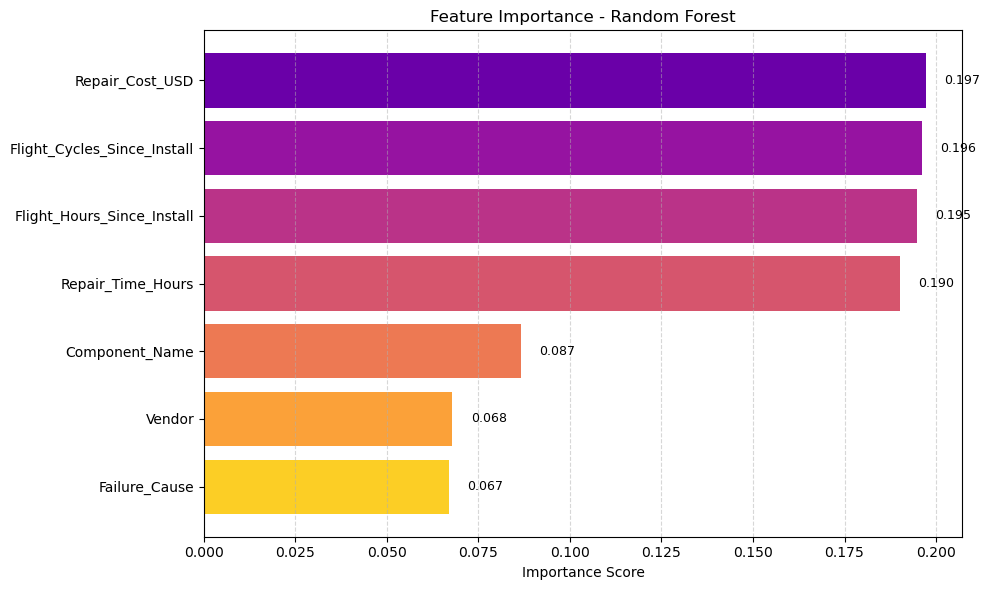

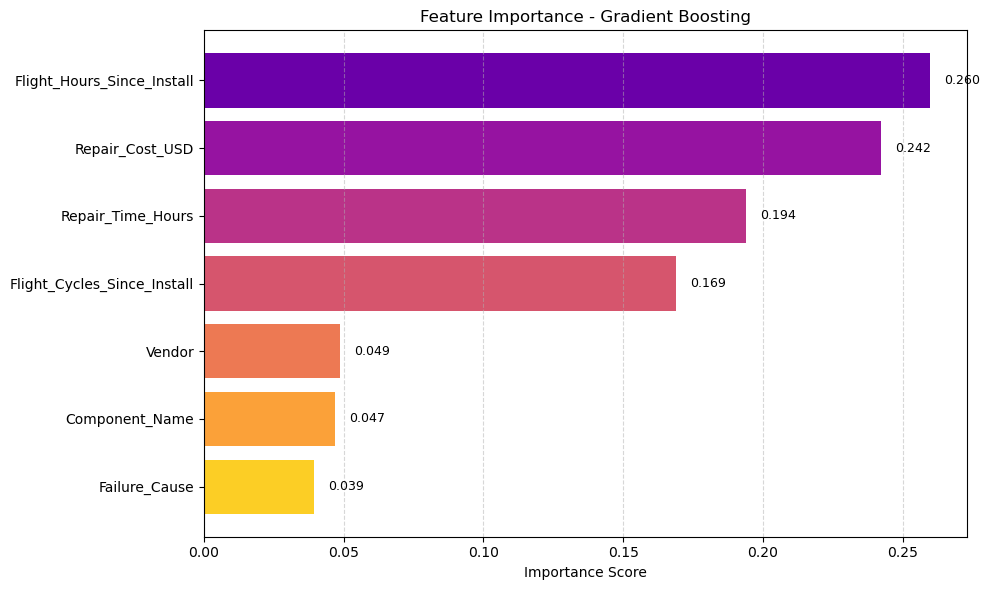

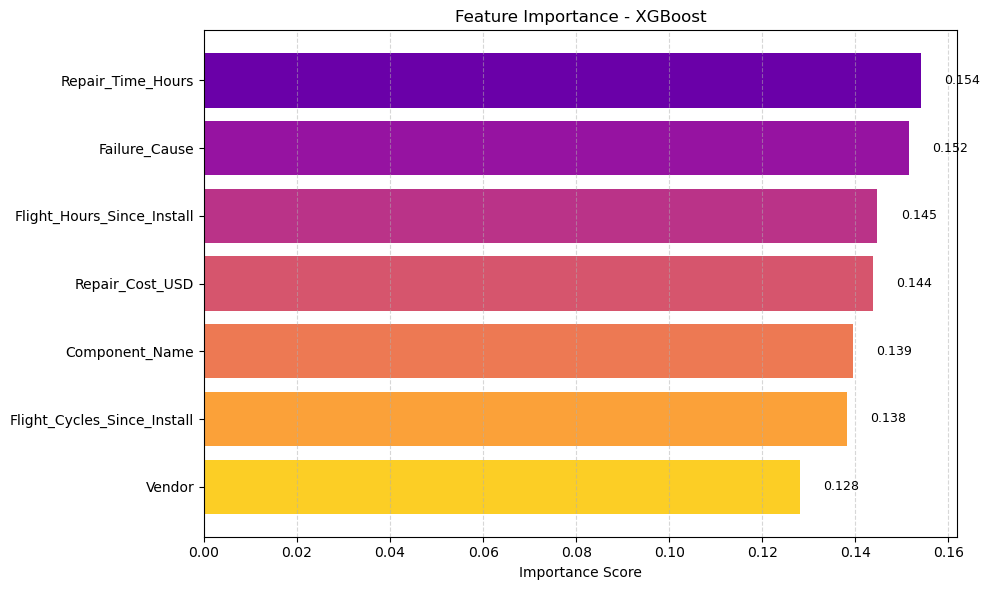

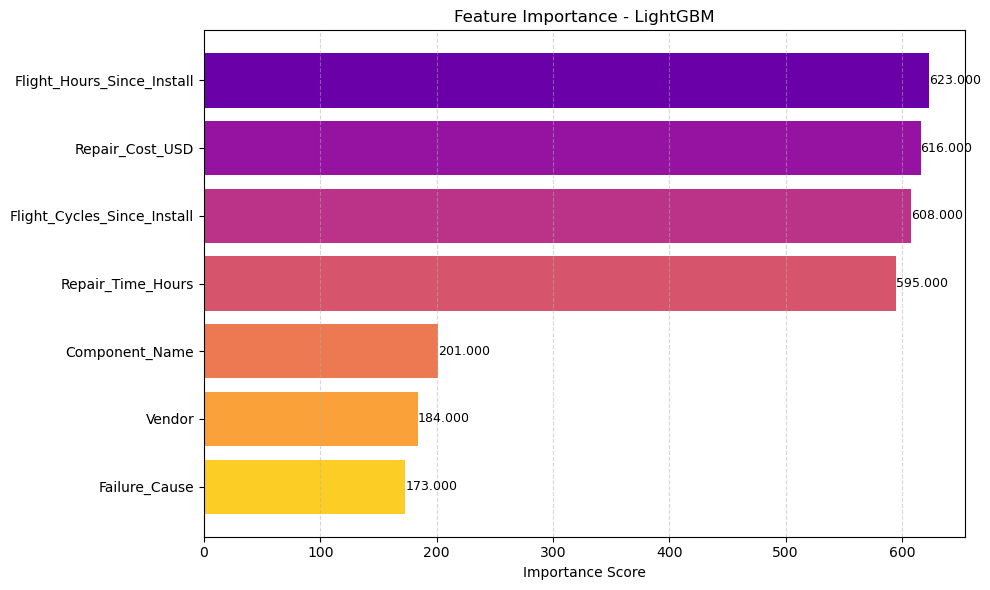

In [48]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Aggregate feature importances from tree-based models
feature_importance_results = {}

for model_name, model in models.items():
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importance_results[model_name] = dict(zip(X.columns, importances))

# Plotting for each model
for model_name, feature_scores in feature_importance_results.items():
    sorted_scores = dict(sorted(feature_scores.items(), key=lambda x: x[1], reverse=True))
    
    features = list(sorted_scores.keys())
    scores = list(sorted_scores.values())
    colors = cm.plasma(np.linspace(0.2, 0.9, len(features)))

    plt.figure(figsize=(10, 6))
    bars = plt.barh(features, scores, color=colors)
    plt.xlabel("Importance Score")
    plt.title(f"Feature Importance - {model_name}")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Annotate values
    for bar in bars:
        plt.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}",
            va='center',
            ha='left',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()